In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [50]:
!rm -rf /content/data
!mkdir -p /content/data/raw
%cd /content/data/raw
!curl --fail --location-trusted -u user:SewerML4294lsdaw321 -o FILELIST.txt \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/FILELIST.txt"

!curl --fail --location-trusted -u user:SewerML4294lsdaw321 -o SewerML_Train.csv \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/SewerML_Train.csv"

!curl --fail --location-trusted -u user:SewerML4294lsdaw321 -o SewerML_Val.csv \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/SewerML_Val.csv"

!curl --fail --location-trusted -u user:SewerML4294lsdaw321 -o SewerML_Test.csv \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/SewerML_Test.csv"


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/data/raw
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   309  100   309    0     0    251      0  0:00:01  0:00:01 --:--:--   251
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 55.9M  100 55.9M    0     0  4790k      0  0:00:11  0:00:11 --:--:-- 10.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7164k  100 7164k    0     0  1152k      0  0:00:06  0:00:06 --:--:-- 1631k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Spe

In [51]:
!curl -sI --location-trusted -u user:SewerML4294lsdaw321 \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/train00.zip" | sed -n '1,20p'


HTTP/1.1 200 OK
Date: Tue, 20 Jan 2026 10:50:00 GMT
Server: Apache
Expires: Thu, 19 Nov 1981 08:52:00 GMT
Cache-Control: no-store, no-cache, must-revalidate, post-check=0, pre-check=0
Pragma: no-cache
Strict-Transport-Security: max-age=31536000
X-XSS-Protection: 1; mode=block
X-Content-Type-Options: nosniff
Content-Security-Policy: script-src 'self' http://*.google.com https://*.deic.dk https://*.sciencedata.dk https://sciencedata.dk https://kube.sciencedata.dk https://kube.sciencedata.dk:8443 'unsafe-inline' 'unsafe-eval' http://*.googleapis.com https://*.googleapis.com https://*.google.com https://*.gstatic.com https://code.jquery.com https://d3js.org https://cdnjs.cloudflare.com https://unpkg.com https://maxcdn.bootstrapcdn.com https://kube.sciencedata.dk https://kube.sciencedata.dk:8443 https://*.deic.dk https://*.sciencedata.dk https://sciencedata.dk; style-src 'self' 'unsafe-inline' http://*.googleapis.com https://*.googleapis.com https://*.google.com https://*.gstatic.com https:

In [52]:
!curl --fail --location-trusted \
  --retry 10 --retry-delay 3 --retry-connrefused \
  -u user:SewerML4294lsdaw321 \
  -C - -o train00.zip \
"https://sciencedata.dk/public/Large%20AAU%20files/Sewer_ML/train00.zip"


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 18.3G  100 18.3G    0     0  15.9M      0  0:19:39  0:19:39 --:--:-- 12.0M      0  0:15:53  0:06:37  0:09:16 20.5M 0  0:17:50  0:08:44  0:09:06 11.1M0  0:18:56  0:10:39  0:08:17 12.7M4:38  0:05:08 15.2M  0  15.8M      0  0:19:47  0:17:21  0:02:26 13.9M9:40  0:19:09  0:00:31 17.3M


In [53]:
!ls -lh train00.zip
!file train00.zip
!unzip -t train00.zip | tail -n 20


-rw-r--r-- 1 root root 19G Jan 20 11:09 train00.zip
train00.zip: Zip archive data, at least v2.0 to extract, compression method=deflate
    testing: 00041664.png             OK
    testing: 00041665.png             OK
    testing: 00041666.png             OK
    testing: 00041667.png             OK
    testing: 00041668.png             OK
    testing: 00041669.png             OK
    testing: 00041670.png             OK
    testing: 00041671.png             OK
    testing: 00041672.png             OK
    testing: 00041673.png             OK
    testing: 00041674.png             OK
    testing: 00041675.png             OK
    testing: 00041676.png             OK
    testing: 00041677.png             OK
    testing: 00041678.png             OK
    testing: 00041679.png             OK
    testing: 00041680.png             OK
    testing: 00041681.png             OK
    testing: 00041682.png             OK
No errors detected in compressed data of train00.zip.


In [54]:
!mkdir -p train_images
!unzip -q train00.zip -d train_images


In [55]:
!find train_images -type f -name "*.png" | head
!find train_images -type f -name "*.png" | wc -l


train_images/00000001.png
train_images/00000002.png
train_images/00000003.png
train_images/00000004.png
train_images/00000005.png
train_images/00000006.png
train_images/00000007.png
train_images/00000008.png
train_images/00000009.png
train_images/00000010.png
find: ‘standard output’: Broken pipe
find: write error
33139


In [56]:
import pandas as pd

train_df = pd.read_csv("SewerML_Train.csv")
val_df   = pd.read_csv("SewerML_Val.csv")

print(train_df.shape, val_df.shape)


(1040129, 22) (130046, 22)


In [57]:
for c in label_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce").fillna(0).astype(int)


In [58]:
for c in label_cols:
    val_df[c] = pd.to_numeric(val_df[c], errors="coerce").fillna(0).astype(int)


In [59]:
train_df[label_cols].dtypes


VA    int64
RB    int64
OB    int64
PF    int64
DE    int64
FS    int64
IS    int64
RO    int64
IN    int64
AF    int64
BE    int64
FO    int64
GR    int64
PH    int64
PB    int64
OS    int64
OP    int64
OK    int64
ND    int64
dtype: object

In [62]:
subset_df = train_df[train_df[filename_col].isin(img_map.keys())].reset_index(drop=True)
print(subset_df.shape)


(33139, 22)


In [63]:
from torch.utils.data import DataLoader

ds = SewerMLDataset(subset_df)
dl = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0)

x, y = next(iter(dl))
print(x.shape, y.shape)


TypeError: SewerMLDataset.__init__() missing 4 required positional arguments: 'Y', 'idxs', 'filename_col', and 'img_map'

In [ ]:
train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()


In [ ]:
import numpy as np
import pandas as pd

Y_train = (
    train_df[label_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(np.float32)
    .values
)

print("Y_train dtype:", Y_train.dtype, "shape:", Y_train.shape)


In [ ]:
subset_mask = train_df[filename_col].astype(str).isin(img_map.keys()).values
subset_idx = np.where(subset_mask)[0]

print("Subset size:", len(subset_idx))


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class SewerMLDataset(Dataset):
    def __init__(self, df, Y, idxs, filename_col, img_map, transform=None):
        self.df = df
        self.Y = Y
        self.idxs = idxs
        self.filename_col = filename_col
        self.img_map = img_map
        self.transform = transform

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        ridx = int(self.idxs[i])
        fname = str(self.df.iloc[ridx][self.filename_col])
        img = Image.open(self.img_map[fname]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        y = torch.from_numpy(self.Y[ridx])  # already float32
        return img, y


In [ ]:
from torch.utils.data import DataLoader

ds = SewerMLDataset(train_df, Y_train, subset_idx, filename_col, img_map, transform=train_tfms)
dl = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0)

x, y = next(iter(dl))
print(x.shape, y.shape, y.dtype)


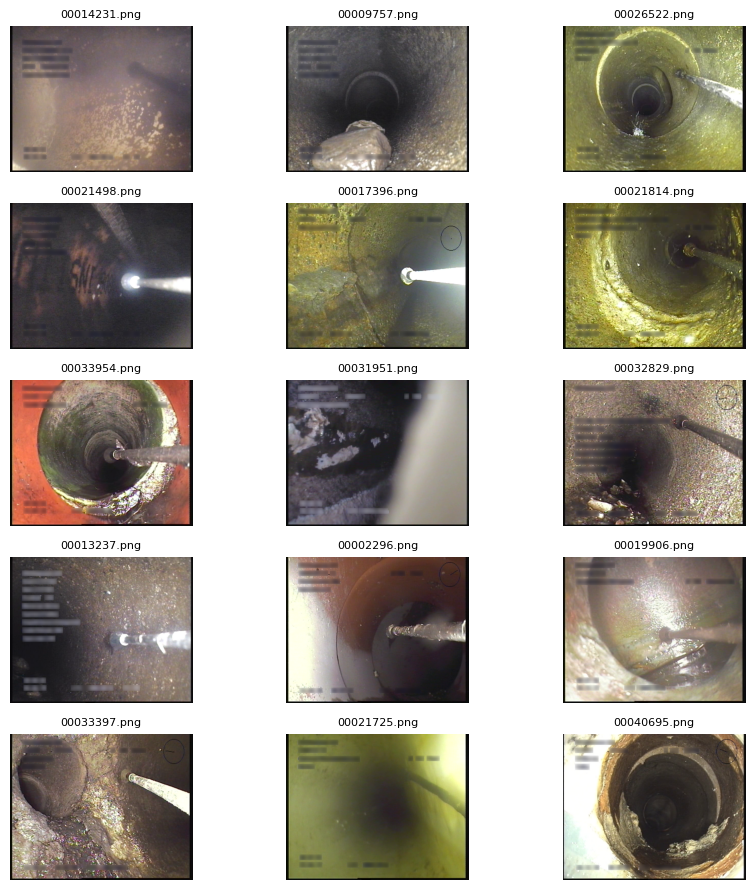

In [70]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_grid(img_map, k=15):
    names = list(img_map.keys())
    if len(names) == 0:
        print("❌ No images in img_map")
        return

    sample = random.sample(names, min(k, len(names)))
    cols = 3
    rows = (len(sample) + cols - 1) // cols

    plt.figure(figsize=(9,9))
    for i, name in enumerate(sample):
        img = Image.open(img_map[name]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(name, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(img_map, k=15)



In [71]:
# =========================
# Cell 19 — Config + columns (safe definitions)
# =========================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# If you already have these, this will not break anything.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 19 labels as per dataset description
label_cols = [
    "VA","RB","OB","PF","DE","FS","IS","RO","IN","AF","BE","FO","GR","PH","PB","OS","OP","OK","ND"
]

def guess_filename_col(df: pd.DataFrame) -> str:
    cols = [c.strip() for c in df.columns]
    # common candidates
    candidates = ["Filename", "filename", "file", "image", "ImageId", "image_id", "id", "ID"]
    for cand in candidates:
        for c in cols:
            if c.lower() == cand.lower():
                return c
    # fallback: first column that is non-numeric and not a label
    non_label = [c for c in cols if c not in label_cols]
    for c in non_label:
        if df[c].dtype == "object":
            return c
    # last resort: first column not in labels
    return non_label[0] if non_label else df.columns[0]

# Ensure column whitespace is clean (you already did this, but safe)
train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()

filename_col = guess_filename_col(train_df)
print("Using filename column:", filename_col)

# Force labels to int/0-1 (safe)
for c in label_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce").fillna(0).astype(int)
    val_df[c]   = pd.to_numeric(val_df[c], errors="coerce").fillna(0).astype(int)

print("Train:", train_df.shape, "Val:", val_df.shape)
print("Label columns OK:", all(c in train_df.columns for c in label_cols))


Using filename column: Filename
Train: (1040129, 22) Val: (130046, 22)
Label columns OK: True


In [72]:
# =========================
# Cell 20 — Build img_map from extracted images folder
# =========================
from glob import glob

# Set your actual extracted folders here if needed:
# Example in your notebook: /content/data/raw/train_images
TRAIN_IMG_DIR = Path("train_images")   # change if your folder is different
VAL_IMG_DIR   = Path("val_images")     # optional; only if you extracted val images separately

def build_img_map(*folders: Path):
    mp = {}
    for folder in folders:
        if folder is None or not Path(folder).exists():
            continue
        for p in folder.rglob("*.png"):
            name = p.name
            mp[name] = str(p)
    return mp

# If you only extracted train zip, keep only TRAIN_IMG_DIR
img_map = build_img_map(TRAIN_IMG_DIR, VAL_IMG_DIR)

print("Images found:", len(img_map))
print("Sample keys:", list(img_map.keys())[:5])

# Keep only rows that have images available
train_mask = train_df[filename_col].astype(str).apply(lambda x: os.path.basename(x)).isin(img_map.keys())
val_mask   = val_df[filename_col].astype(str).apply(lambda x: os.path.basename(x)).isin(img_map.keys())

train_df = train_df[train_mask].reset_index(drop=True)
val_df   = val_df[val_mask].reset_index(drop=True)

print("After filtering to extracted images:")
print("Train:", train_df.shape, "Val:", val_df.shape)

# Normalize filenames to basename (important!)
train_df[filename_col] = train_df[filename_col].astype(str).apply(os.path.basename)
val_df[filename_col]   = val_df[filename_col].astype(str).apply(os.path.basename)


Images found: 33139
Sample keys: ['00031740.png', '00001687.png', '00031629.png', '00024287.png', '00024474.png']
After filtering to extracted images:
Train: (33139, 22) Val: (0, 22)


In [75]:
# =========================
# Cell 21 — Transforms
# =========================
from torchvision import transforms

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [76]:
# =========================
# Cell 22 — Build Y arrays + datasets + dataloaders
# =========================
from torch.utils.data import DataLoader

Y_train = train_df[label_cols].astype(np.float32).values
Y_val   = val_df[label_cols].astype(np.float32).values

train_idx = np.arange(len(train_df))
val_idx   = np.arange(len(val_df))

train_ds = SewerMLDataset(train_df, Y_train, train_idx, filename_col, img_map, transform=train_tfms)
val_ds   = SewerMLDataset(val_df,   Y_val,   val_idx,   filename_col, img_map, transform=val_tfms)

BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_dl))
print("Batch:", xb.shape, yb.shape, yb.dtype)


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32, 19]) torch.float32


In [77]:
# =========================
# Cell 23 — Model + loss (pos_weight for imbalance)
# =========================
# If timm isn't installed in your environment, uncomment:
# !pip install -q timm

import timm
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_LABELS = len(label_cols)

model = timm.create_model("resnet50", pretrained=True, num_classes=NUM_LABELS)
model = model.to(DEVICE)

# pos_weight = (#neg / #pos) per label (helps imbalance a lot)
pos = Y_train.sum(axis=0)
neg = (Y_train.shape[0] - pos)
pos_weight = torch.tensor((neg / (pos + 1e-6)), dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Device:", DEVICE)
print("pos_weight (first 5):", pos_weight[:5].detach().cpu().numpy())


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Device: cuda
pos_weight (first 5): [  1.525261   14.306698    3.6218967 105.9       103.21069  ]


In [80]:
# =========================
# Cell 24 — Metrics + train/eval loops (micro-F1)
# =========================
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

@torch.no_grad()
def predict_probs(model, dl):
    model.eval()
    all_probs = []
    all_true  = []
    for xb, yb in dl:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_true.append(yb.numpy())
    return np.vstack(all_probs), np.vstack(all_true)

def micro_f1_from_probs(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return f1_score(y_true.ravel(), y_pred.ravel(), average="micro", zero_division=0)

def train_one_epoch(model, dl):
    model.train()
    total_loss = 0.0
    for xb, yb in tqdm(dl, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
    return total_loss / len(dl.dataset)

@torch.no_grad()
def eval_epoch(model, dl):
    model.eval()
    total_loss = 0.0
    for xb, yb in dl:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(dl.dataset)


In [81]:
# =========================
# Cell 25 — Train
# =========================
EPOCHS = 5  # start small; increase later (10–20)
best_f1 = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_dl)
    va_loss = eval_epoch(model, val_dl)

    va_probs, va_true = predict_probs(model, val_dl)
    va_f1 = micro_f1_from_probs(va_true, va_probs, thr=0.5)

    scheduler.step()

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_microF1@0.5={va_f1:.4f}")

    if va_f1 > best_f1:
        best_f1 = va_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print("Best val micro-F1@0.5:", best_f1)

# Load best
model.load_state_dict(best_state)


  0%|          | 0/1036 [00:00<?, ?it/s]

ZeroDivisionError: float division by zero

In [ ]:
# =========================
# Cell 26 — Threshold tuning (per-label thresholds)
# =========================
def tune_thresholds(y_true, y_prob, grid=np.linspace(0.05, 0.95, 19)):
    """
    Find best threshold per label that maximizes F1 for that label.
    """
    best_thr = np.zeros(y_true.shape[1], dtype=np.float32)
    best_f1s = np.zeros(y_true.shape[1], dtype=np.float32)

    for j in range(y_true.shape[1]):
        yt = y_true[:, j].astype(int)
        yp = y_prob[:, j]
        best = -1
        best_t = 0.5
        for t in grid:
            pred = (yp >= t).astype(int)
            f1 = f1_score(yt, pred, average="binary", zero_division=0)
            if f1 > best:
                best = f1
                best_t = t
        best_thr[j] = best_t
        best_f1s[j] = best

    return best_thr, best_f1s

va_probs, va_true = predict_probs(model, val_dl)
thr_vec, per_label_f1 = tune_thresholds(va_true, va_probs)

# Micro-F1 with tuned thresholds
va_pred_tuned = (va_probs >= thr_vec.reshape(1, -1)).astype(int)
micro_tuned = f1_score(va_true.ravel(), va_pred_tuned.ravel(), average="micro", zero_division=0)

print("Micro-F1 @0.5 :", micro_f1_from_probs(va_true, va_probs, 0.5))
print("Micro-F1 tuned:", micro_tuned)

pd.DataFrame({"label": label_cols, "thr": thr_vec, "f1": per_label_f1}).sort_values("f1", ascending=False).head(10)


In [ ]:
# =========================
# Cell 27 — Inference on test + submission (adapt to your test.csv format)
# =========================
from PIL import Image

# Load your test csv (change path/name if needed)
# Example (Kaggle-style): test_df = pd.read_csv("test.csv")
# In SewerML official split, you may have a separate Test csv
# If you don't have it yet, skip this cell.
# test_df = pd.read_csv("test.csv")

def predict_test(model, df, filename_col, img_map, transform):
    model.eval()
    probs_all = []
    bs = 64
    names = df[filename_col].astype(str).apply(os.path.basename).tolist()

    for i in tqdm(range(0, len(names), bs)):
        batch_names = names[i:i+bs]
        imgs = []
        ok_names = []
        for n in batch_names:
            if n in img_map:
                img = Image.open(img_map[n]).convert("RGB")
                imgs.append(transform(img))
                ok_names.append(n)
            else:
                # If missing image, put dummy (or handle separately)
                pass

        if len(imgs) == 0:
            continue

        xb = torch.stack(imgs).to(DEVICE)
        with torch.no_grad():
            logits = model(xb)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.append(probs)

    return np.vstack(probs_all)

# Example usage (once you have test_df and test_images mapped in img_map):
# test_probs = predict_test(model, test_df, filename_col, img_map, val_tfms)
# test_pred  = (test_probs >= thr_vec.reshape(1,-1)).astype(int)
#
# submission = pd.DataFrame(test_pred, columns=label_cols)
# submission.insert(0, filename_col, test_df[filename_col].astype(str).apply(os.path.basename).values[:len(submission)])
# submission.to_csv("submission.csv", index=False)
# submission.head()


In [82]:
ls

FILELIST.txt      SewerML_Train.csv  train00.zip
SewerML_Test.csv  SewerML_Val.csv    train_images/
